In [2]:
import pandas as pd

df_clean = pd.read_csv("../data/processed/df_clean.csv")

exclude_cols = ["CUST_ID", "target", "cluster_kmeans", "cluster_dbscan",
                 "est_atypique_dbscan", "cluster_final"]

X = df_clean.drop(columns=exclude_cols)
y = df_clean["target"]

X.columns.tolist()

['BALANCE',
 'PURCHASES',
 'ONEOFF_PURCHASES',
 'INSTALLMENTS_PURCHASES',
 'CASH_ADVANCE',
 'CREDIT_LIMIT',
 'PAYMENTS']

### train/test split

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(7159, 7) (1790, 7)
target
Clients Premium              0.379103
Clients à Faible Activité    0.349490
Clients à Risque             0.271407
Name: proportion, dtype: float64
target
Clients Premium              0.379330
Clients à Faible Activité    0.349721
Clients à Risque             0.270950
Name: proportion, dtype: float64


### building the scikit-learn pipeline

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)
pipeline.score(X_test, y_test)

0.9659217877094972

### Confusion matrix

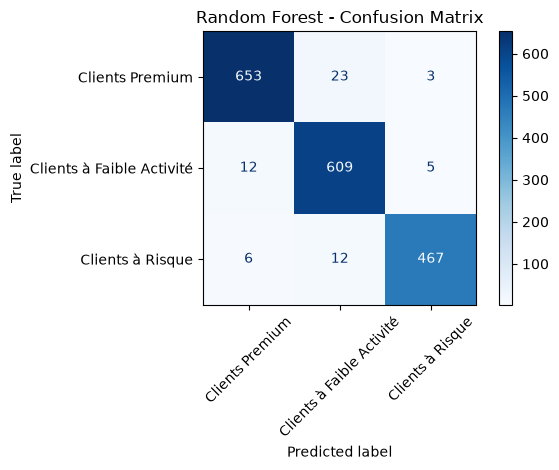

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

### Precision, recall, F1

In [6]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

                           precision    recall  f1-score   support

          Clients Premium       0.97      0.96      0.97       679
Clients à Faible Activité       0.95      0.97      0.96       626
         Clients à Risque       0.98      0.96      0.97       485

                 accuracy                           0.97      1790
                macro avg       0.97      0.97      0.97      1790
             weighted avg       0.97      0.97      0.97      1790



### Other 3 models

In [7]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

models = {
    "SVM": SVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000)
}

trained_pipelines = {"Random Forest": pipeline}
print(f"Random Forest: {pipeline.score(X_test, y_test):.4f}")

for name, clf in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", clf)
    ])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    print(f"{name}: {pipe.score(X_test, y_test):.4f}")

Random Forest: 0.9659
SVM: 0.9089
Decision Tree: 0.9374
Logistic Regression: 0.9106


### rf > dt > logisticR > svm acording to their score

In [8]:
import time
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

comparison_results = []

for name, pipe in trained_pipelines.items():
    start = time.time()
    pipe.fit(X_train, y_train)  # re-fit to time it properly
    train_time = time.time() - start

    y_pred = pipe.predict(X_test)

    comparison_results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="weighted"),
        "recall": recall_score(y_test, y_pred, average="weighted"),
        "f1_score": f1_score(y_test, y_pred, average="weighted"),
        "train_time_sec": train_time
    })

comparison_df = pd.DataFrame(comparison_results).sort_values("f1_score", ascending=False)
comparison_df

,model,accuracy,precision,recall,f1_score,train_time_sec
0,Random Forest,0.965922,0.966254,0.965922,0.965979,0.479625
2,Decision Tree,0.937430,0.937495,0.937430,0.937381,0.025953
3,Logistic Regression,0.910615,0.911176,0.910615,0.910627,0.047559
1,SVM,0.908939,0.910174,0.908939,0.908838,0.317694


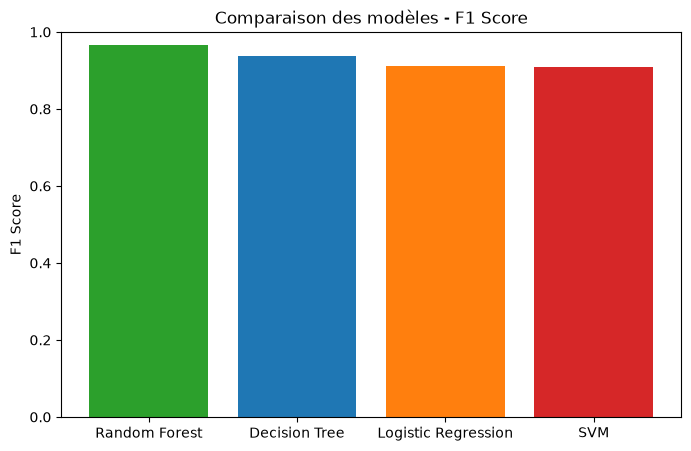

In [9]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["model"], comparison_df["f1_score"], color=["#2ca02c", "#1f77b4", "#ff7f0e", "#d62728"])
plt.ylabel("F1 Score")
plt.title("Comparaison des modèles - F1 Score")
plt.ylim(0, 1)
plt.show()

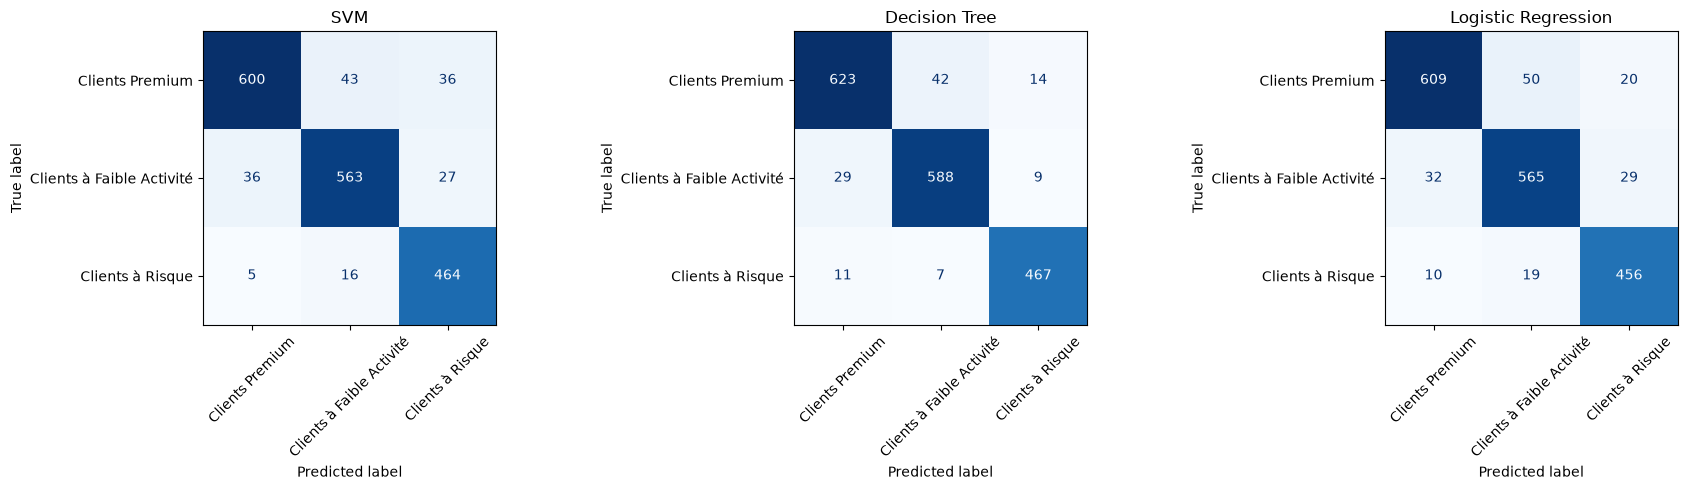

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, ["SVM", "Decision Tree", "Logistic Regression"]):
    pipe = trained_pipelines[name]
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=pipe.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe.classes_)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

### cross-validation

In [11]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring="f1_weighted")

print(cv_scores)
print(f"Mean F1: {cv_scores.mean():.4f}, Std: {cv_scores.std():.4f}")

[0.96984201 0.96589012 0.97821043 0.96649618 0.96034553]
Mean F1: 0.9682, Std: 0.0059


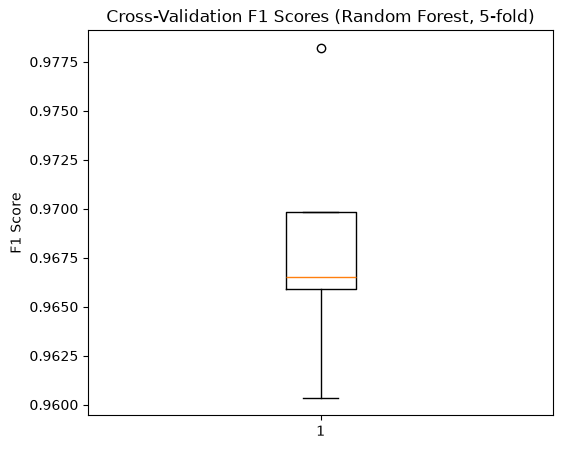

In [12]:
plt.figure(figsize=(6, 5))
plt.boxplot(cv_scores)
plt.ylabel("F1 Score")
plt.title("Cross-Validation F1 Scores (Random Forest, 5-fold)")
plt.show()

### Grid Search

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    pipeline, param_grid, cv=5, scoring="f1_weighted", n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

Best params: {'classifier__max_depth': 20, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}
Best CV F1: 0.9682901079524227


### Evaluate the tuned model

In [14]:
best_pipeline = grid_search.best_estimator_

y_pred_best = best_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_best))

                           precision    recall  f1-score   support

          Clients Premium       0.97      0.96      0.97       679
Clients à Faible Activité       0.95      0.97      0.96       626
         Clients à Risque       0.98      0.96      0.97       485

                 accuracy                           0.97      1790
                macro avg       0.97      0.97      0.97      1790
             weighted avg       0.97      0.97      0.97      1790



### Feature Importance

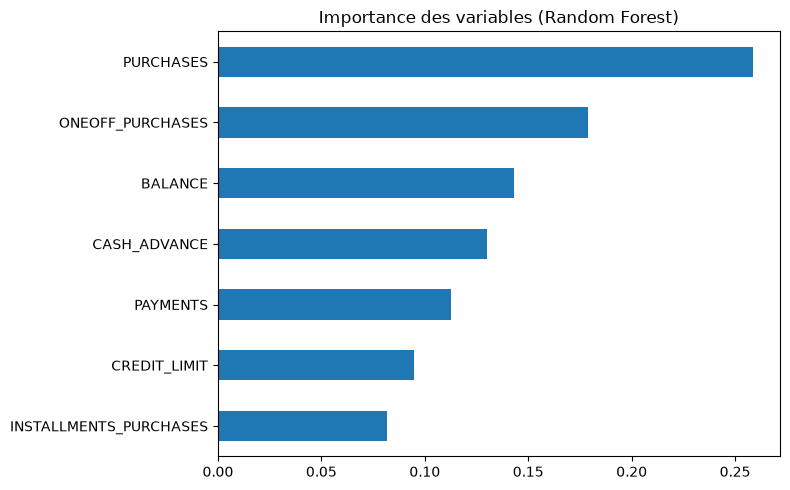

In [15]:
importances = best_pipeline.named_steps["classifier"].feature_importances_

feat_imp = pd.Series(importances, index=X.columns).sort_values()

plt.figure(figsize=(8,5))
feat_imp.plot(kind="barh")
plt.title("Importance des variables (Random Forest)")
plt.tight_layout()
plt.show()

### Saving the pipeline

In [19]:
import joblib

joblib.dump(best_pipeline, "../models/best_pipeline.joblib")

['../models/best_pipeline.joblib']